## Brand Control Analysis

Fracture mechanics characterisation of unmodified brand chips. No baking or moisture variation, serves as a baseline for comparing Trial 1 and Trial 2 results.

n = 10 chips. Same apparatus and derivation as Trial 2 (see Trial 1 §2.2 for formula definitions).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams['figure.dpi'] = 120

## Setup & Apparatus

> **Apparatus constants**: same as Trial 2. Update here and re-run if geometry differs.

In [2]:
R_mm   = 25.0
r_mm   = 15.0
t_mm   = 2.0
nu     = 0.3
v_mm_s = 5.0

R = R_mm * 1e-3
r = r_mm * 1e-3
t = t_mm * 1e-3

---

## Part 2: Fracture Mechanics Analysis

#### 2.1 Load & Clean Data

In [3]:
df = pd.read_csv('dataProcessing_brand.csv')

# Extract chip number from filename
df['Chip'] = df['TrialName'].str.extract(r'(\d+)').astype(int)
df = df.sort_values('Chip').reset_index(drop=True)

print(f'Chips loaded: {len(df)}')
df[['Chip', 'dt', 'PeakForce_N', 'MaxForce_N', 'FractureEnergy_J']]

Chips loaded: 10


,Chip,dt,PeakForce_N,MaxForce_N,FractureEnergy_J
0,1,3.2125,7.328497,18.400958,0.065339
1,2,3.7000,13.150565,14.950684,0.076943
2,3,2.9625,7.609416,10.397550,0.076010
3,4,3.8000,7.836605,9.686902,0.059141
4,5,3.3125,6.315465,17.361547,0.077888
5,6,3.5125,3.867828,15.583641,0.079203
6,7,3.4875,8.712868,13.991293,0.066155
7,8,3.0125,5.884222,25.445585,0.095147
8,9,3.6875,3.256598,8.448947,0.051803
9,10,3.6750,11.876067,12.525936,0.077205


#### 2.2 Derived Quantities

Computed identically to Trial 2. Formulae defined in Trial 1 §2.2.

In [4]:
# Displacement at first peak
df['delta_c_mm'] = df['dt'] * v_mm_s
df['delta_c_m']  = df['delta_c_mm'] * 1e-3

# Fracture energy density G_c (J/m²)
A_punch = np.pi * r**2
df['G_c_Jm2'] = df['FractureEnergy_J'] / A_punch

# Elastic modulus E (MPa)
df['E_Pa']  = (df['PeakForce_N'] / df['delta_c_m']) * (3 * (1 - nu**2) * R**2) / (4 * t**3)
df['E_MPa'] = df['E_Pa'] * 1e-6

# Critical stress sigma_c (MPa)
geo_term = (1 + nu) * np.log(R / r) + (1 - nu) * (R**2 - r**2) / (2 * R**2)
df['sigma_c_Pa']  = (3 * df['PeakForce_N']) / (4 * np.pi * t**2) * geo_term
df['sigma_c_MPa'] = df['sigma_c_Pa'] * 1e-6

# Fracture toughness K_Ic
df['K_Ic'] = np.sqrt(df['G_c_Jm2'] * df['E_Pa'])

print('Derived columns added.')
df[['Chip', 'delta_c_mm', 'G_c_Jm2', 'E_MPa', 'sigma_c_MPa', 'K_Ic']].round(3)

Derived columns added.


,Chip,delta_c_mm,G_c_Jm2,E_MPa,sigma_c_MPa,K_Ic
0,1,16.062,92.436,24.327,0.388,47420.667
1,2,18.500,108.852,37.902,0.697,64232.001
2,3,14.812,107.532,27.391,0.403,54272.027
3,4,19.000,83.668,21.992,0.415,42895.520
4,5,16.562,110.188,20.332,0.335,47331.902
5,6,17.562,112.049,11.743,0.205,36273.558
6,7,17.438,93.591,26.642,0.462,49934.543
7,8,15.062,134.606,20.830,0.312,52951.036
8,9,18.438,73.286,9.418,0.173,26271.737
9,10,18.375,109.223,34.462,0.629,61351.573


#### 2.3 Summary Statistics

In [5]:
cols = ['PeakForce_N', 'MaxForce_N', 'FractureEnergy_J', 'G_c_Jm2', 'E_MPa', 'sigma_c_MPa', 'K_Ic']
desc = df[cols].describe().round(3)

# Add CV row
cv_row = (df[cols].std() / df[cols].mean() * 100).round(1)
cv_row.name = 'CV (%)'
desc = pd.concat([desc, cv_row.to_frame().T])
desc

,PeakForce_N,MaxForce_N,FractureEnergy_J,G_c_Jm2,E_MPa,sigma_c_MPa,K_Ic
count,10.000,10.000,10.000,10.000,10.000,10.000,10.000
mean,7.584,14.679,0.072,102.543,23.504,0.402,48293.456
std,3.124,5.000,0.012,17.258,8.877,0.166,11278.984
min,3.257,8.449,0.052,73.286,9.418,0.173,26271.737
25%,5.992,10.930,0.066,92.725,20.456,0.318,44004.616
50%,7.469,14.471,0.076,108.192,23.160,0.396,48677.605
75%,8.494,16.917,0.078,109.947,27.204,0.450,53941.779
max,13.151,25.446,0.095,134.606,37.902,0.697,64232.001
CV (%),41.200,34.100,16.800,16.800,37.800,41.200,23.400


#### 2.4 Distributions

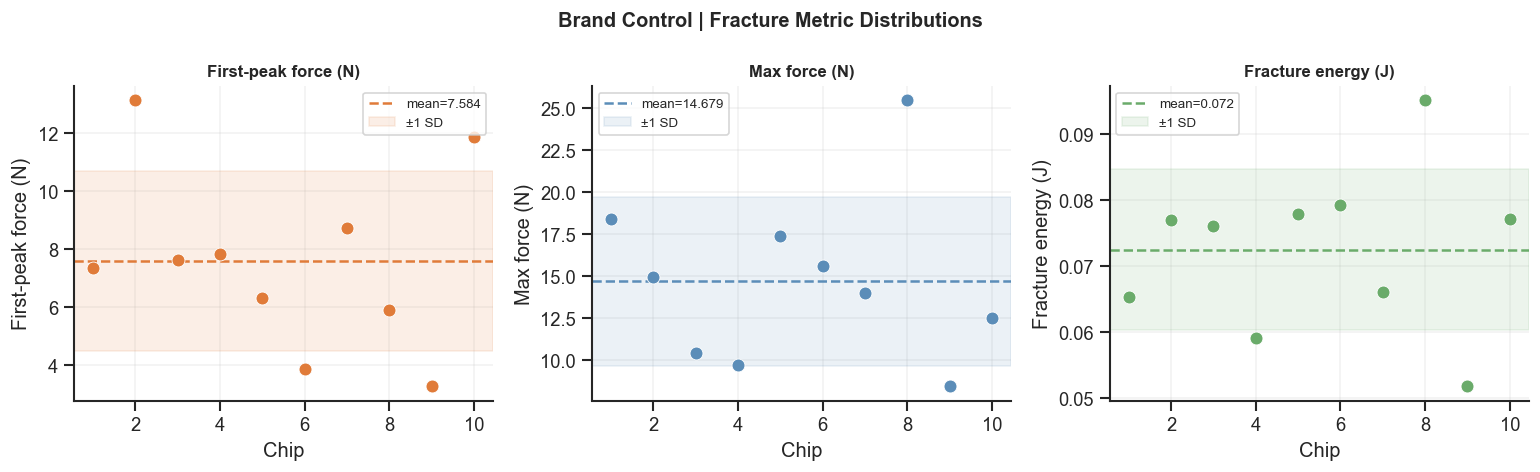

In [8]:
plot_cols = [
    ('PeakForce_N',      'First-peak force (N)',   '#e07b39'),
    ('MaxForce_N',       'Max force (N)',           '#5b8db8'),
    ('FractureEnergy_J', 'Fracture energy (J)',     '#6aab6a'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Brand Control | Fracture Metric Distributions', fontsize=12, fontweight='bold')

for ax, (col, label, color) in zip(axes, plot_cols):
    vals = df[col].dropna()
    ax.scatter(df['Chip'], vals, color=color, s=60, edgecolors='white', linewidth=0.5, zorder=3)
    ax.axhline(vals.mean(), color=color, linewidth=1.5, linestyle='--', label=f'mean={vals.mean():.3f}')
    ax.axhspan(vals.mean() - vals.std(), vals.mean() + vals.std(),
               alpha=0.12, color=color, label=f'±1 SD')
    ax.set_xlabel('Chip')
    ax.set_ylabel(label)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

sns.despine()
plt.tight_layout()
plt.show()

#### 2.5 Cross-Trial CoV Comparison

CoV (coefficient of variation = SD/mean) measures scatter independent of scale. Lower is better.

               Metric  Trial 1 CoV (%)  Trial 2 CoV (%)  Brand CoV (%)
               F_peak             68.1             39.6           41.2
                F_max             37.7             19.8           34.1
E_f (fracture energy)             50.4             37.7           16.8


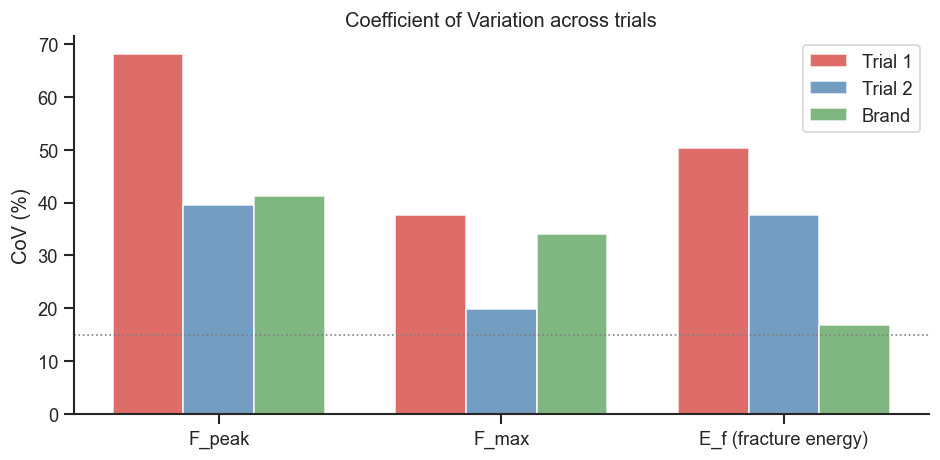

In [7]:
# Trial 1 and Trial 2 CoV values from prior analyses
cov_table = pd.DataFrame({
    'Metric':   ['F_peak', 'F_max', 'E_f (fracture energy)'],
    'Trial 1 CoV (%)': [68.1, 37.7, 50.4],
    'Trial 2 CoV (%)': [39.6, 19.8, 37.7],
    'Brand CoV (%)': [
        round(df['PeakForce_N'].std()    / df['PeakForce_N'].mean()    * 100, 1),
        round(df['MaxForce_N'].std()     / df['MaxForce_N'].mean()     * 100, 1),
        round(df['FractureEnergy_J'].std() / df['FractureEnergy_J'].mean() * 100, 1),
    ]
})
print(cov_table.to_string(index=False))

# Bar chart
x = np.arange(3)
w = 0.25
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w, cov_table['Trial 1 CoV (%)'], w, label='Trial 1', color='#d9534f', alpha=0.85)
ax.bar(x,     cov_table['Trial 2 CoV (%)'], w, label='Trial 2', color='#5b8db8', alpha=0.85)
ax.bar(x + w, cov_table['Brand CoV (%)'],   w, label='Brand',   color='#6aab6a', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(cov_table['Metric'])
ax.set_ylabel('CoV (%)')
ax.set_title('Coefficient of Variation across trials')
ax.legend()
ax.axhline(15, color='grey', linewidth=1, linestyle=':', label='engineering threshold (~15%)')
sns.despine()
plt.tight_layout()
plt.show()

---

### Conclusions

The brand chips provide a no-bake baseline with no moisture variation. Any differences in CoV relative to Trials 1 and 2 reflect the effect of baking-induced variability (puffing, uneven drying) rather than measurement noise.